## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>7 - Lagrangian Relaxation</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 7.1

Consider the following model:

$$
\begin{align}
\max \quad &
x_1 + 2x_2
\\[1ex]
\text{s.t.} \quad
& 2𝑥1 + 𝑥2 \leq 2
\\[1ex]
& x_1, x_2 \in \{0,1\}
\\[1ex]
\end{align}
$$

### a) Make a graphical representation of the problem and find the optimal solution and the linear programming relaxation.

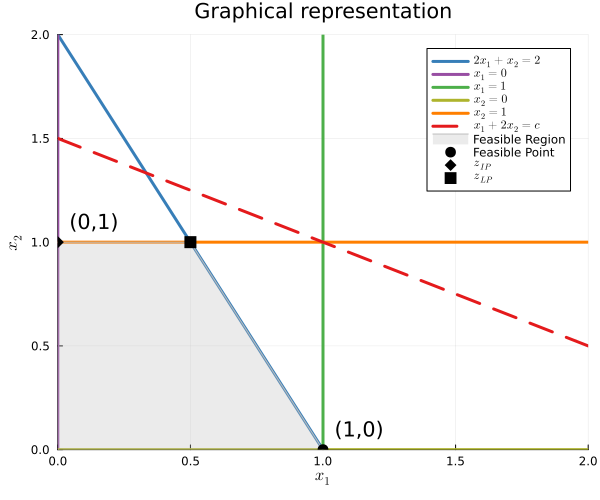

In [1]:
using Plots, LaTeXStrings
gr()

# Define colors
cb_blue   = "#377eb8"
cb_orange = "#ff7f00"
cb_green  = "#4daf4a"
cb_purple = "#984ea3"
cb_black  = "#000000"
cb_gray   = "#bdbdbd"
cb_red    = "#e41a1c"


cb_new   = "#aeb42dff"
cb_red    = "#e41a1c"
cb_gray   = "#bdbdbd"
cb_black  = "#000000"

# Define x values
x = 0:0.01:2

# Define constraint lines
line1 = -2 .* x .+ 2        # x2 = -2x1 + 2
line2 = zero.(x)            # x2 = 0
line3 = one.(x)             # x2 = 1
line_obj = -0.5 .* x .+ 1.5 # x2 = -0.5x1 + 1.5 (dashed red)

# Plot constraints
plot(x, line1, color=cb_blue, label=L"2x_1 + x_2 = 2", linewidth=3)
plot!([0, 0], [0, 2], color=cb_purple, label=L"x_1 = 0", linewidth=3)
plot!([1, 1], [0, 2], color=cb_green, label=L"x_1 = 1", linewidth=3)
plot!(x, line2, color=cb_new, label=L"x_2 = 0", linewidth=3)
plot!(x, line3, color=cb_orange, label=L"x_2 = 1", linewidth=3)

# Dashed red line (objective)
plot!(x, line_obj, color=cb_red, linewidth=3, linestyle=:dash, label=L"x_1 + 2x_2 = c")

# Fill between: Region 1 (between x₂=0 and x₂=1, for x₁ in [0,0.5])
x_fill1 = 0:0.01:0.5
fill1_top = one.(x_fill1)
fill1_bot = zero.(x_fill1)
plot!(x_fill1, fill1_top, fillrange=fill1_bot, fillalpha=0.3, color=cb_gray, label="")

# Fill between: Region 2 (between x₂=0 and x₂=-2x₁+2, for x₁ in [0.5,1])
x_fill2 = 0.5:0.01:1.0
fill2_top = -2 .* x_fill2 .+ 2
fill2_bot = zero.(x_fill2)
plot!(x_fill2, fill2_top, fillrange=fill2_bot, fillalpha=0.3, color=cb_gray, label="Feasible Region")

# Bullet points
scatter!([1], [0], color=cb_black, markersize=6, label="Feasible Point")
scatter!([0], [1], color=cb_black, markershape = :diamond, markersize=6, label=L"z_{IP}")
# Insert a point at (0.5,1) with black color and square type
scatter!([0.5], [1], color=cb_black, markershape = :square, markersize=6, label=L"z_{LP}")

# Annotate points (optional)
annotate!(1.05, 0.1, text("(1,0)", :left))
annotate!(0.05, 1.1, text("(0,1)", :left))

# Axis labels and layout
xlabel!(L"x_1")
ylabel!(L"x_2")
title!("Graphical representation")
xlims!(0, 2)
ylims!(0, 2)
plot!(legend=true, grid=true, size=(600,500))

### b) Find the Lagrangian relaxation for the constraint 2𝑥1 + 𝑥2 ≤ 2. Make a graphical representation of the dual’s solution. Is there a duality gap?

#### Solution

The Lagrangian relaxation is:
$$
\begin{aligned}
L(\lambda) : \quad \max_{x_1,x_2} \quad & 2 \lambda + (1 - 2\lambda) x_1 + (2 - \lambda) x_2\\
\text{s.t.} \quad & x_1, x_2 \in \{0,1\}
\end{aligned}
$$

and the dual problem is:
$$
D : \min_{\lambda \ge 0} \ z_{L(\lambda)}
$$

We can find the optimal value of the dual problem ($z_D$) graphically by plotting the function $z_{L(\lambda)}$ for $\lambda \ge 0$ and identifying its minimum point.

Since $L(\lambda)$ is a maximization problem over binary variables, the optimal values of $x_1$ and $x_2$ depend on the signs of their respective coefficients:
$$
z_{L(\lambda)} = 2\lambda + \underbrace{(1 - 2\lambda)}_{c_1}x_1 + \underbrace{(2 - \lambda)}_{c_2}x_2
$$

Since we are maximizing and $x_1, x_2 \in \{0, 1\}$:

- $x_1$ should be $1$ if $c_1 \geq 0$ and $0$ if $c_1 < 0$.
- $x_2$ should be $1$ if $c_2 \geq 0$ and $0$ if $c_2 < 0$.

To find the boundaries, we set the coefficients to zero:

- $c_1 = 0 \implies 1 - 2\lambda = 0 \implies \mathbf{\lambda = 0.5}$
- $c_2 = 0 \implies 2 - \lambda = 0 \implies \mathbf{\lambda = 2}$

These values divide the possible values of $\lambda$ into the three intervals: $[0, 0.5)$, $[0.5, 2)$, and $[2, \infty)$. @tbl-B-7-1 maps these intervals to the corresponding optimal binary decisions and the resulting linear expression for $z_{L{(\lambda)}}$. At the breakpoints $\lambda=0.5$ and $\lambda = 2$, the Lagrangian subproblem admits multiple optimal solutions; the half-open interval convention is adopted for notational clarity.

<div align="center">

| $x_1$ | $x_2$ | $\lambda$        | $z_{L(\lambda)}$  |
|-------|-------|------------------|---------------|
| $0$   | $0$   | $\lambda \geq 2$ | $2\lambda$    |
| $0$   | $1$   | $0.5 \leq \lambda < 2$ | $\lambda + 2$ |
| $1$   | $1$   | $0 \leq \lambda < 0.5$ | $3 - \lambda$ |

</div>

Plotting these segments as a function of $\lambda$ yields the graph in the following figure. As can be seen, the minimum value is obtained at the point where the function's definition changes, at $\lambda = 0.5$. Therefore, the optimal value of the dual problem is $z_D = L(0.5) = 2.5$. 

The duality gap for this problem is $z_D - z_{IP} = 2.5 - 2 = 0.5$. This gap indicates that the Lagrangian relaxation does not provide the same optimal value as the original integer problem. The value of the dual's solution ($z_D = 2.5$) corresponds to the solution of the linear programming relaxation ($z_{LP}$). 

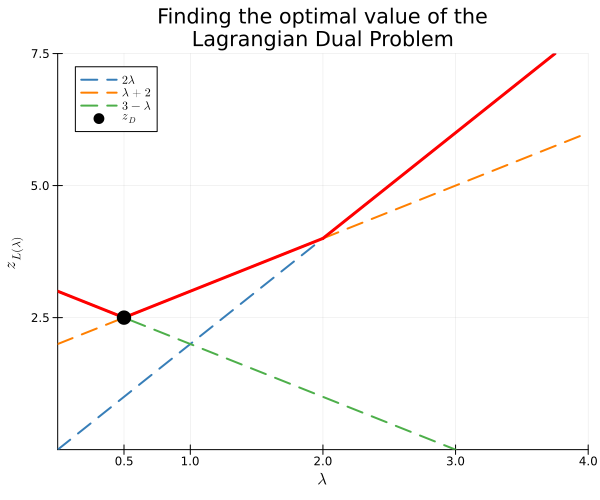

In [2]:
using Plots, LaTeXStrings

# Define colors
cb_blue   = "#377eb8"
cb_orange = "#ff7f00"
cb_green  = "#4daf4a"

# Define the domain
λ = 0:0.01:4

# Define the piecewise functions
f1(x) = 2x
f2(x) = x + 2
f3(x) = -x + 3

# Base plot (empty, to set axis)
plot(
    xlabel = L"\lambda", ylabel = L"z_{L(\lambda)}",
    xlims = (0, 4), ylims = (0, 7.5),
    xticks = [0.5, 1, 2, 3, 4],
    yticks = [2.5, 5, 7.5],
    legend = false,
    grid = true,
    framestyle = :origin,
    title = "Finding the optimal value of the\nLagrangian Dual Problem"
)

# Blue segments (full domain)
plot!(λ, f1.(λ), color = cb_blue, label=L"2\lambda", linestyle=:dash, lw=2)
plot!(λ, f2.(λ), color = cb_orange, label=L"\lambda+2", linestyle=:dash, lw=2)
plot!(λ, f3.(λ), color = cb_green, label=L"3-\lambda", linestyle=:dash, lw=2)

# Red segments (limited domain to overwrite parts)
plot!(2:0.01:4, f1.(2:0.01:4), color = :red, label="", lw=3)
plot!(0.5:0.01:2, f2.(0.5:0.01:2), color = :red, label="", lw=3)
plot!(0:0.01:0.5, f3.(0:0.01:0.5), color = :red, label="", lw=3)

# Highlight the optimal dual solution
scatter!([0.5], [2.5], color=:black, markersize=8, label=L"z_D")

p = plot!(legend=true, grid=true, size=(600,500))

### c) Find the optimal solution of the dual using the subgradient method.

### Solution

The following Julia code implements the subgradient method to find the optimal solution of the dual problem. The code includes functions to solve the original integer program exactly, perform Lagrangian relaxation, and iterate through the subgradient method to update the Lagrange multiplier. It also tracks the lower and upper bounds for convergence analysis.

-------------- Starting Lagrangian Relaxation -------------
Iter. |   λ    |  Lower Bound  |   Upper Bound  |   Gap
-----------------------------------------------------------
    1 | 0.0000 |          -Inf |         3.0000 |       Inf
    2 | 0.5000 |        2.0000 |         2.5000 |     0.500
    3 | 0.1667 |        2.0000 |         2.5000 |     0.500
    4 | 0.4167 |        2.0000 |         2.5000 |     0.500
    5 | 0.6167 |        2.0000 |         2.5000 |     0.500
    6 | 0.4500 |        2.0000 |         2.5000 |     0.500
    7 | 0.5929 |        2.0000 |         2.5000 |     0.500
    8 | 0.4679 |        2.0000 |         2.5000 |     0.500
    9 | 0.5790 |        2.0000 |         2.5000 |     0.500
   10 | 0.4790 |        2.0000 |         2.5000 |     0.500
   11 | 0.5699 |        2.0000 |         2.5000 |     0.500
-----------------------------------------------------------
Lagrangian relaxation stopped. No improvement in UB for 10 iterations.
------------------------- Results

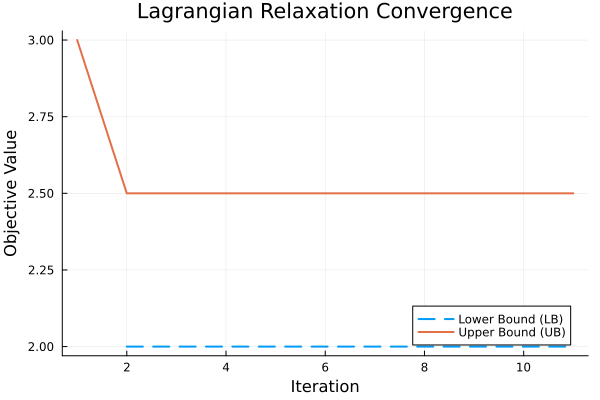

In [3]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Printf # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Function to solve the original integer program exactly
function solve_exact()
    # Create the model
    model =  JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define binary variables
    @variable(model, x[1:2], Bin)
    # Define the objective function
    @objective(model, Max, x[1] + 2 * x[2])
    # Define the constraint
    @constraint(model, 2 * x[1] + x[2] <= 2)
    # Solve the model
    JuMP.optimize!(model)
    # Get results
    x_opt =  JuMP.value.(x)
    obj_value = JuMP.objective_value(model)
    return x_opt, obj_value
end

# Function to perform Lagrangian relaxation
function solve_lagrangian(iterations = 100)
    # Initialize variables
    x = [0, 0]  # Initial solution
    λ = 0.0     # Initial Lagrange multiplier
    λ_best = λ  # To track the best λ found
    α = 0.1     # Step size
    LB = -Inf   # Best lower bound found so far
    UB = Inf    # Best upper bound found so far
    LB_history = Float64[] # To store LB values for plotting
    UB_history = Float64[] # To store UB values for plotting

    # Logic to stop if no improvement in UB for a certain number of iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("-------------- Starting Lagrangian Relaxation -------------")
    println("Iter. |   λ    |  Lower Bound  |   Upper Bound  |   Gap")
    println("-"^59)

    for t in 1:iterations
        # Compute primal solution at current λ
        x[1] = (1 - 2λ > 0) ? 1 : 0
        x[2] = (2 - λ > 0) ? 1 : 0

        # Lagrangian dual value
        zL = 2λ + max(0, 1 - 2λ) + max(0, 2 - λ)
        
        # Check for improvement in UB
        if zL < UB 
            UB = zL
            λ_best = λ              # Update the best λ found
            no_improve_counter = 0  # Reset counter if we have an improvement
        else
            no_improve_counter += 1
            # Check if we have reached the limit of no improvement
            if no_improve_counter >= no_improve_limit
                println("-"^59)
                println("Lagrangian relaxation stopped. ",
                        "No improvement in UB for $no_improve_limit iterations.")
                break
            end
        end

        # Feasible primal value
        if 2x[1] + x[2] <= 2
            zP = x[1] + 2x[2]
            LB = max(LB, zP)
        end
        
        # Store LB and UB values for plotting
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Print iteration details
        @printf("%5d | %5.4f | %13.4f | %14.4f | %9.3f\n", t, λ, LB, UB, UB - LB)

        # Subgradient
        s = 2 - (2x[1] + x[2])
        
        # Update step size (Diminishing step size)
        α = 1 / (1 + t)

        # Update λ (project onto λ ≥ 0)
        λ = max(0, λ - α * s)
    end
    return UB, λ_best, LB_history, UB_history
end

# Solve using Lagrangian relaxation
UB, λ_best, LB_history, UB_history = solve_lagrangian()

# Solve exactly to find the optimal value
xO, zO = solve_exact()

println("------------------------- Results -------------------------")
@printf("Optimal Dual Solution (λ = %4.2f): %4.2f\n", λ_best, UB)
@printf("Optimal Primal Solution: x = [%d, %d] with objective value %4.2f\n", xO[1], xO[2], zO)
@printf("Duality gap: %4.2f - %4.2f = %4.2f\n", UB, zO, UB - zO)

# Plot convergence of LB and UB
plot_convergence("Lagrangian Relaxation Convergence",LB_history, UB_history)

---

## Exercise 7.2

Consider the following exercises related to P-Median Problems:

### a) Apply the subgradient method to get a bound on the optimal solution of the P-Median Problem using 𝑝 = 3. Use the following dataset: [exercise_pmp.csv](exercise_pmp.csv).

----------- Starting Lagrangian Relaxation -----------
Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)
------------------------------------------------------
     1 |           0.000 |     1105032.279 |   100.000
    10 |      364622.007 |      499653.789 |    27.025
    20 |      378322.099 |      499653.789 |    24.283
    30 |      475081.593 |      499653.789 |     4.918
    40 |      496400.884 |      499653.789 |     0.651
    50 |      499525.953 |      499653.789 |     0.026
    58 |      499607.511 |      499653.789 |     0.009
------------------------------------------------------
Convergence achieved: Duality gap is below tolerance.
------------------------------------------------------
Solving exact PMP for comparison...
Final LB: 499607.511 | Exact: 499653.789 | Duality Gap: 46.278 (0.009%)


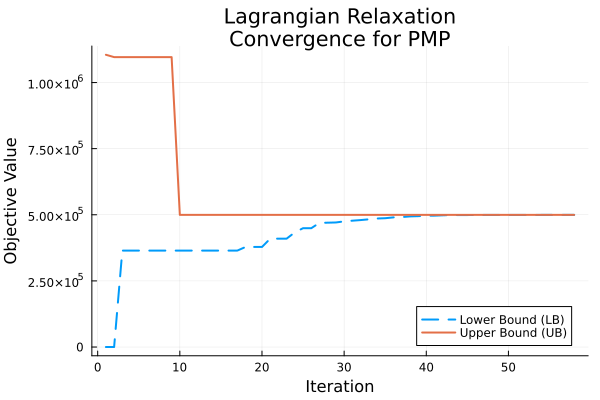

In [4]:
using JuMP          # Modeling language
using HiGHS         # Solver
using CSV           # For reading CSV files
using Distances     # Distance computations
using LinearAlgebra # For dot/norm calculations
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Data structure to hold the p-median problem data
struct PMedianData
    D::Matrix{Float64} # Distance matrix
    p::Int             # Number of facilities
    n::Int             # Number of clients/locations
    # Constructor
    function PMedianData(file_path::String; p::Int)
        # Load latitude and longitude data
        coordinates = CSV.read(file_path, CSV.Tables.matrix, header=true)
        # Compute Haversine distance matrix
        D = pairwise(Haversine(), coordinates, dims=1)
        return new(D, p, size(D, 1))
    end
end

# Function to improve the chosen facilities using local search
function improve_facilities(D, chosen)
    n = size(D,1)
    # Initialize current solution and cost
    current = copy(chosen)
    current_cost = sum(minimum(D[:, current], dims=2))
    # Main loop for local search
    improved = true
    while improved
        improved = false
        best_cost = current_cost
        best_set = current
        # Create a set for quick membership checking
        current_set = Set(current)
        # Iterate over all possible swaps
        for facility_out in current
            for facility_in in 1:n
                # Skip if the facility is already in the current set
                if facility_in in current_set
                    continue
                end
                candidate = copy(current)
                # Perform the swap
                idx = findfirst(==(facility_out), candidate)
                candidate[idx] = facility_in
                # Calculate the cost of the candidate solution
                candidate_cost = sum(minimum(D[:, candidate], dims=2))
                # Check if this candidate solution is better than the best found so far
                if candidate_cost < best_cost
                    best_cost = candidate_cost
                    best_set = candidate
                    improved = true
                end
            end
        end
        # Update current solution if an improvement was found
        if improved
            current = best_set
            current_cost = best_cost
        end
    end
    return current, current_cost
end

# Function to solve the PMP exactly
function solve_pmp_exact(data::PMedianData)
    # Index range
    N = 1:data.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[i in N, j in N], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, dot(data.D, x))
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in N) == data.p)
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i in N], sum(x[i,j] for j in N) == 1)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i in N, j in N], x[i,j] <= x[j,j])
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    return JuMP.objective_value(model)
end

# Function to solve PMP using Lagrangian Relaxation
function solve_pmp_lagrangian(file_path; p = 3, iteration_max=500, gap_tolerance = 1e-6, print_feedback_iteration = 10, local_search_iteration = 10)
    # Load problem data
    data = PMedianData(file_path, p = p)

    # Initialization
    λ = zeros(data.n)
    θ, LB, UB = 2.0, -Inf, Inf
    LB_history, UB_history = Float64[], Float64[]
    no_improve, limit = 0, 10

    println("-"^11," Starting Lagrangian Relaxation ", "-"^11)
    println("Iter.  |   Lower Bound   |   Upper Bound   |   Gap (%)")
    println("-"^54)

    # Main loop
    for iteration in 1:iteration_max
        # --- Step 1: Lower Bound ---
        
        # 1a. Calculate attractiveness of each facility
        costs = data.D .- λ
        facility_scores = vec(sum(min.(0.0, costs), dims=1))
        
        # 1b. Select the p best facilities (smallest value)
        chosen = sortperm(facility_scores)[1:data.p]
        
        # 1c. Calculate the LB
        current_LB = sum(facility_scores[chosen]) + sum(λ)
        
        # 1d. Update Best LB
        if current_LB > LB
            LB, no_improve = current_LB, 0
        else
            no_improve += 1
            if no_improve >= limit
                θ = max(0.5, θ * 0.95)
                no_improve = 0
            end
        end
        
        # 1e. Store LB history
        push!(LB_history, LB)

        # --- Step 2: Upper Bound (Heuristic) ---

        # 2a. Two strategies: every `local_search_iteration` iterations, improve the facilities; 
        #     otherwise, assign each customer to the closest facility
        if iteration % local_search_iteration == 0
            # Local search to improve the chosen facilities
            improved_chosen, current_UB = improve_facilities(data.D, chosen)
        else
            # For each customer, assign to the closest facility
            current_UB = sum(minimum(data.D[:, chosen], dims=2))
        end

        # 2b. Update the best upper bound if this heuristic solution is better
        UB = min(UB, current_UB)
        
        # 2c. Store upper bound history
        push!(UB_history, UB)

        # 2d. Stopping Criterion
        gap = isfinite(UB) ? abs(UB - LB) / (UB + 1e-10) : Inf
        if isfinite(gap) && gap <= gap_tolerance
            @printf("%6d | %15.3f | %15.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
            println("-"^54)
            println("Convergence achieved: Duality gap is below tolerance.")
            break
        end

        # --- Step 3: Update Multipliers ---
        # s_i = 1 - (times the client i was served in the relaxed problem)

        # 3a. Calculate subgradient
        x_relaxed = (costs[:, chosen] .< 0)
        # x_relaxed = (costs[:, improved_chosen] .< 0)
        s = 1.0 .- vec(sum(x_relaxed, dims=2))
        
        # 3b. Determine the step size α_k (Held-Karp style)
        α = θ * (abs(UB - LB) / (norm(s)^2 + 1e-10))

        # 3c. Update the multipliers
        λ .+= α .* s

        # Print iteration details
        if iteration == 1 || iteration % print_feedback_iteration == 0
            @printf("%6d | %15.3f | %15.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
        end
    end

    # Final summary and Exact solve for comparison
    println("-"^54)
    println("Solving exact PMP for comparison...")
    exact_objective = solve_pmp_exact(data)
    @printf("Final LB: %.3f | Exact: %.3f | Duality Gap: %.3f (%.3f%%)\n", LB, exact_objective, abs(exact_objective - LB), 100 * abs(exact_objective - LB)/exact_objective)

    # Plot convergence history
    plot_convergence("Lagrangian Relaxation\nConvergence for PMP", LB_history, UB_history)
end

# Example usage
solve_pmp_lagrangian("data/exercise_pmp.csv", p=3, iteration_max = 500, gap_tolerance = 1e-4, print_feedback_iteration = 10, local_search_iteration = 10)

### b) Apply the subgradient method to get a bound on the optimal solution of the fault-tolerant P-Median Problem [35] using 𝑝 = 5 and 𝑟 = 2. Use the following dataset: [exercise_pmp.csv](exercise_pmp.csv).

[35] I. Vasilyev, A. V. Ushakov, N. Maltugueva, and A. Sforza, “An effective
heuristic for large-scale fault-tolerant k-median problem,” Soft Computing,
vol. 23, no. 9, pp. 2959–2967, 2019, doi: 10.1007/s00500-018-3130-0.

### Solution

Given the following formulation of the Fault-tolerant P-Median Problem:

$$
\begin{aligned}
\text{FT-PMP} : \quad \min_{x} \quad & \sum_{i \in N}\sum_{j \in N} d_{ij} x_{ij} &  \\
\text{s.t.} \quad & \sum_{j \in N} x_{jj} = p & & &  (1)\\
& \sum_{j \in N} x_{ij} = r & \forall i \in N && (2)\\
& x_{ij} \le x_{jj} &  \forall i,j \in N && (3)\\
& x_{ij} \in \{0,1\} &  \forall i, j \in N && (4)\\
\end{aligned}
$$

where $N$ is the set of customers/facilities, $d_{ij}$ is the distance from customer $i$ to facility $j$, and $r$ is the number of facilities that each customer is assigned to.

We relax constraint (2) using Lagrangian multipliers $\lambda_i \in \mathbb{R}$ for each customer $i$. The resulting Lagrangian relaxation is:

$$
\begin{aligned}
L(\lambda) : \quad \min_{x} \quad & \sum_{i \in N}\sum_{j \in N} (d_{ij} - \lambda_i) x_{ij} + r \sum_{i \in N} \lambda_i &  \\
\text{s.t.} \quad & \sum_{j \in N} x_{jj} = p & & &  (1)\\
& x_{ij} \le x_{jj} &  \forall i,j \in N && (3)\\
& x_{ij} \in \{0,1\} &  \forall i, j \in N && (4)\\
\end{aligned}
$$

The subgradient for updating the lagrangian multipliers is given by:
$$
s_i = r - \sum_{j \in N} x_{ij}
$$

Interpretation of the subgradient:
- if $s_i > 0$, it means that customer $i$ is currently assigned to fewer than $r$ facilities, so we need to increase $\lambda_i$ to encourage more assignments for that customer.
- if $s_i < 0$, it means that customer $i$ is currently assigned to more than $r$ facilities, so we need to decrease $\lambda_i$ to discourage excess assignments for that customer.
- if $s_i = 0$, it means that customer $i$ is currently assigned to exactly $r$ facilities, so we do not need to adjust $\lambda_i$ for that customer.

The following code solves the Lagrangian relaxation the fault-tolerant p-median problem.

--- Starting Lagrangian Relaxation for Fault-tolerant P-Median ---
Iter. |     Lower Bound     |     Upper Bound     |     Gap (%)
------------------------------------------------------------------
    1 |               0.000 |         2199112.825 |   100.000
   21 |         1013421.779 |         1184550.274 |    14.447
   41 |         1169956.922 |         1184550.274 |     1.232
   61 |         1184028.228 |         1184550.274 |     0.044
   81 |         1184341.234 |         1184550.274 |     0.018
  101 |         1184406.542 |         1184550.274 |     0.012
  121 |         1184426.491 |         1184550.274 |     0.010
  126 |         1184438.234 |         1184550.274 |     0.009
------------------------------------------------------------------
Convergence achieved: Duality gap is below tolerance.
------------------------------------------------------------------
Solving exact FT-PMP for comparison...
Final LB: 1184438.234 | Exact: 1184550.274 | Duality Gap: 112.040 (0.009%)


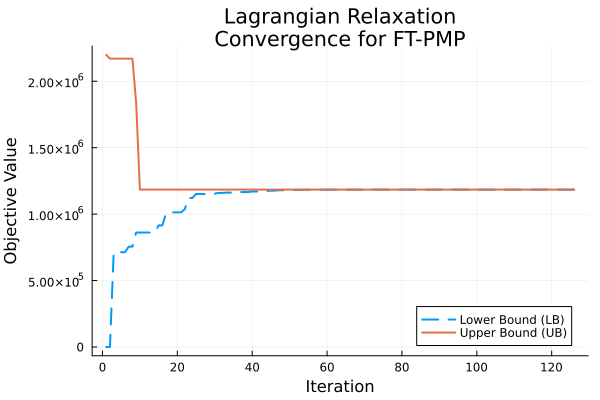

In [5]:
using JuMP          # Modeling language
using HiGHS         # Solver
using CSV           # For reading CSV files
using Distances     # Distance computations
using LinearAlgebra # For norm calculations
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Data structure to hold the Fault-tolerant P-Median Problem data
struct FTPMedianData
    D::Matrix{Float64} # Distance matrix
    p::Int             # Number of facilities
    r::Int             # Fault tolerance level
    n::Int             # Number of clients/locations
    # Constructor
    function FTPMedianData(file_path::String; p::Int, r::Int)
        # Load latitude and longitude data
        coordinates = CSV.read(file_path, CSV.Tables.matrix, header=true)
        # Compute Haversine distance matrix
        D = pairwise(Haversine(), coordinates, dims=1)
        return new(D, p, r, size(D, 1))
    end
end

# Function to solve the FT-PMP exactly
function solve_ft_pmp_exact(data::FTPMedianData)
    # Index range
    N = 1:data.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[i in N, j in N], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, dot(data.D, x))
    # Constraint: Each customer assigned to r facilities
    @constraint(model, [i in N], sum(x[i,j] for j in N) == data.r)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i in N, j in N], x[i,j] <= x[j,j])
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in N) == data.p)
    # Run the solver 
    JuMP.optimize!(model)
    return JuMP.objective_value(model)
end

# Function to evaluate the cost of a given solution S
function evaluate_solution(data, S)
    cost = 0.0
    for i in 1:data.n
        dists = data.D[i, collect(S)]
        cost += sum(partialsort(dists, 1:data.r))
    end
    return cost
end

# Function to perform local search by swapping facilities
function local_search_swap(data, initial_open)
    S = Set(initial_open)
    # Initialize current cost
    current_cost = evaluate_solution(data, S)
    # Main loop for local search
    improved = true
    while improved
        improved = false
        # Best improvement found in this iteration
        best_delta = 0.0 
        best_move = nothing
        # Generate lists of open and closed facilities
        open_facilities = collect(S)
        closed_facilities = setdiff(1:data.n, open_facilities)
        # Try swapping each open facility with each closed facility
        for f in open_facilities
            for g in closed_facilities
                # Create a new solution by swapping f with g
                S_new = copy(S)
                delete!(S_new, f)
                push!(S_new, g)
                # Evaluate the cost of the new solution
                new_cost = evaluate_solution(data, S_new)
                # Calculate the improvement (delta)
                delta = current_cost - new_cost
                # Check if this is the best improvement found so far
                if delta > best_delta + 1e-6
                    best_delta = delta
                    best_move = (f,g,new_cost)
                end
            end
        end
        # If an improvement was found, update the current solution
        if best_move !== nothing
            f,g,new_cost = best_move
            delete!(S,f)
            push!(S,g)
            current_cost = new_cost
            improved = true
        end
    end
    return collect(S), current_cost
end

# Main function to solve FT-PMP using Lagrangian Relaxation
function solve_ft_pmp_lagrangian(file_path; p = 3, r = 2, iteration_max = 500, gap_tolerance = 1e-6, print_feedback_iteration = 10, local_search_iteration = 10)
    # Load problem data
    data = FTPMedianData(file_path, p = p, r = r)

    # Initialization
    λ = zeros(data.n)
    θ, LB, UB = 2.0, -Inf, Inf
    LB_history, UB_history = Float64[], Float64[]
    no_improve, limit = 0, 10

    println("--- Starting Lagrangian Relaxation for Fault-tolerant P-Median ---")
    println("Iter. |     Lower Bound     |     Upper Bound     |     Gap (%)")
    println("-"^66)

    # Main loop
    for iteration in 1:iteration_max
        # --- Step 1: Lower Bound ---

        # 1a. Calculate attractiveness of each facility
        costs = data.D .- λ
        facility_scores = vec(sum(min.(0.0, costs), dims=1))

        # 1b. Select the p best facilities (smallest value)
        chosen = sortperm(facility_scores)[1:data.p]

        # 1c. Calculate the LB
        current_LB = sum(facility_scores[chosen]) + r * sum(λ)

        # 1d. Update Best LB
        if current_LB > LB
            LB = current_LB
            no_improve = 0
        else
            no_improve += 1
            if no_improve >= limit
                θ = max(0.5, θ * 0.5)
                no_improve = 0
            end
        end

        # 1e. Store LB history
        push!(LB_history, LB)

        # --- Step 2: Upper Bound (Heuristic) ---

        # 2a. Local search every `local_search_iteration` iterations, otherwise assign each customer to the "r" closest facilities
        if iteration % local_search_iteration == 0
            # Local search to improve the chosen facilities
            improved_chosen, current_UB = local_search_swap(data, chosen)
        else
            # For each customer, assign them to the "r" closest facilities
            current_UB = sum(sum(partialsort(data.D[i, chosen], 1:data.r)) for i in 1:data.n)
        end

        # 2b. Update the best upper bound if this heuristic solution is better
        UB = min(UB, current_UB)
        
        # 2c. Store upper bound history
        push!(UB_history, UB)

        # 2d. Check convergence
        gap = isfinite(UB) ? abs(UB - LB) / (UB + 1e-10) : Inf
        if isfinite(gap) && gap <= gap_tolerance
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
            println("-"^66)
            println("Convergence achieved: Duality gap is below tolerance.")
            break
        end

        # --- 3. Subgradient update ---

        # 3a. Calculate subgradient
        x_relaxed = (costs[:, chosen] .< 0)
        s = data.r .- vec(sum(x_relaxed, dims=2))

        # 3b. Determine the step size α_k (Held-Karp style)
        α = θ * abs(UB - LB) / (norm(s)^2 + 1e-10)

        # 3c. Update the multipliers
        λ .+= α .* s
        
        # Print iteration results
        if iteration == 1 || iteration % print_feedback_iteration == 1
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
        end
    end

    # Final summary and Exact solve for comparison
    println("-"^66)
    println("Solving exact FT-PMP for comparison...")
    exact_objective = solve_ft_pmp_exact(data)
    @printf("Final LB: %8.3f | Exact: %8.3f | Duality Gap: %5.3f (%5.3f%%)\n", LB, exact_objective, abs(exact_objective - LB), 100 * abs(exact_objective - LB)/exact_objective)

    # Plot convergence
    plot_convergence("Lagrangian Relaxation\nConvergence for FT-PMP", LB_history, UB_history)
end

# Example usage
solve_ft_pmp_lagrangian("data/exercise_pmp.csv", p = 5, r = 2, iteration_max = 500, gap_tolerance = 1e-4, print_feedback_iteration = 20, local_search_iteration = 10)

### c) Apply the subgradient method to get a bound on the optimal solution of the Capacitated P-Median Problem using 𝑝 = 3. Use the following dataset: [exercise_cpmp.csv](data/exercise_cpmp.csv).

### Solution

Given the following formulation of the Capacitated P-Median Problem (CPMP):
$$
\begin{aligned}
\text{CPMP} : \quad \min_{x} \quad & \sum_{i \in N}\sum_{j \in N} d_{ij} x_{ij} &  \\
\text{s.t.} \quad & \sum_{j \in N} x_{jj} = p & & &  (1)\\
& \sum_{j \in N} x_{ij} = 1 & \forall i \in N && (2)\\
& x_{ij} \le x_{jj} &  \forall i,j \in N && (3)\\
& \sum_{i \in N} c_{i} x_{ij} \le C x_{jj} & \forall j \in N && (4)\\
& x_{ij} \in \{0,1\} &  \forall i, j \in N && (5)\\
\end{aligned}
$$

where $N$ is the set of customers/facilities, $d_{ij}$ is the distance from customer $i$ to facility $j$, $c_i$ is the demand of customer $i$, and $C$ is the capacity of facility $j$.

We relax the assignment constraints (2) using Lagrange multipliers $\lambda_i$ for each customer $i$. The resulting Lagrangian relaxation, rearranged to group by facility $j$, is:
$$
\begin{aligned}
\text{L($\lambda$)} : \quad \min_{x} \quad & \sum_{j \in N} \left [ \sum_{i \in N} (d_{ij} - \lambda_i) x_{ij} \right ] + \sum_{i \in N} \lambda_i &  \\
\text{s.t.} \quad & \sum_{j \in N} x_{jj} = p & & &  (1)\\
& x_{ij} \le x_{jj} &  \forall i,j \in N && (3)\\
& \sum_{i \in N} c_{i} x_{ij} \le C x_{jj} & \forall j \in N && (4)\\
& x_{ij} \in \{0,1\} &  \forall i, j \in N && (5)\\
\end{aligned}
$$

The problem now decomposes into $|N|$ independent subproblems, one for each facility $j$. Each subproblem is a 0/1 knapsack problem that determines whether to open facility $j$ and which customers to assign to it, based on the modified costs $(d_{ij} - \lambda_i)$.

--- Starting Lagrangian Relaxation for Capacitated P-Median ---
Iter. |     Lower Bound     |     Upper Bound     |  Gap (%)
---------------------------------------------------------------
    1 |         0.0000 |    126816.6489 |   100.000%
   21 |     64025.3436 |     83545.6408 |    23.365%
   41 |     67737.2846 |     83545.6408 |    18.922%
   61 |     70273.1421 |     83545.6408 |    15.887%
   81 |     71566.4974 |     80855.7658 |    11.489%
  101 |     72108.9813 |     80744.6979 |    10.695%
  121 |     72404.8102 |     80744.6979 |    10.329%
  141 |     72651.2776 |     80744.6979 |    10.023%
---------------------------------------------------------------
Solving exact CPMP for comparison...
Final LB: 72721.408 | Exact: 77837.716 | Duality Gap: 5116.308 (6.573%)


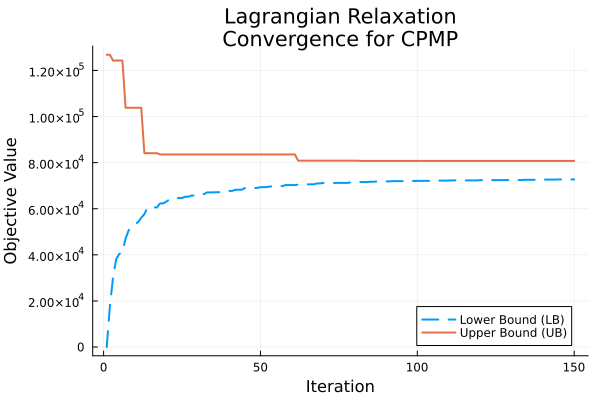

In [6]:
using JuMP          # Modeling language
using HiGHS         # Solver
using LinearAlgebra # For norm calculations
using CSV           # For reading CSV files
using DataFrames    # For handling DataFrame operations
using Distances     # Distance computations
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Data structure to hold the CPMP data
struct CPMPData
    D::Matrix{Float64}       # Distance matrix
    p::Int                   # Number of facilities
    demands::Vector{Float64} # Demand of each client
    C::Float64               # Capacity of each facility
    n::Int                   # Number of clients/locations
    # Constructor
    function CPMPData(file_path::String; p::Int, C::Float64)
        # Load latitude and longitude data
        file = CSV.read(file_path, DataFrame)
        coordinates = Matrix(file[:, [:Latitude, :Longitude]])
        demands = Vector(file[:, :Demand])
        # Compute Haversine distance matrix
        D = pairwise(Haversine(), coordinates, dims=1)
        return new(D, p, demands, C, size(D, 1))
    end
end

# Function to solve the p-median problem exactly
function solve_cpmedian_exact(data::CPMPData)
    N = 1:data.n
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[i in N, j in N], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, dot(data.D, x))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i in N], sum(x[i,j] for j in N) == 1)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i in N, j in N], x[i,j] <= x[j,j])
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in N) == data.p)
    # Constraint: Capacity limit for each facility
    @constraint(model, [j in N], sum(data.demands[i] * x[i, j] for i in N) <= data.C * x[j,j])
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Function to solve subproblem for a given facility j in the relaxed problem 
function solve_subproblem_j(modified_costs, data::CPMPData)
    n = size(modified_costs, 1)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, y[1:n], Bin)  
    # Objective: Minimize total modified cost for facility j
    @objective(model, Min, sum(modified_costs[i] * y[i] for i in 1:n))
    # Constraint: Total demand assigned to facility j cannot exceed capacity
    @constraint(model, sum(data.demands[i] * y[i] for i in 1:n) <= data.C)
    # Run the solver
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model), [JuMP.value(y[i])>0.5 ? 1 : 0 for i in 1:n]
    end
end

# Function to solve subproblem for a given a set of facilities from the relaxed problem
function solve_cpmedian_exact_subset(selected_facilities, data::CPMPData)
    N = 1:data.n
    M = 1:length(selected_facilities)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[i in N, j in M], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(data.D[i, selected_facilities[j]] * x[i,j] for i in N, j in M))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i in N], sum(x[i,j] for j in M) == 1)
    # Constraint: Capacity limit for each facility
    @constraint(model, [j in M], sum(data.demands[i] * x[i, j] for i in N) <= data.C)
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model), 
               [JuMP.value(x[i,j])>0.5 ? selected_facilities[j] : 0 for i in N, j in M]
    else
        error("Optimal solution for subset not found.")
    end
end

# Main Lagrangian Relaxation function
function solve_cpmedian_lagrangian(file_path; p = 3, capacity = 3516, iterations = 50, gap_tolerance = 1e-6, print_feedback_iteration = 20)
    # Load problem data
    data = CPMPData(file_path, p = p, C = capacity)

    # Initialization
    λ = zeros(data.n)
    θ, LB, UB = 0.15, -Inf, Inf
    LB_history, UB_history = Float64[], Float64[]
    no_improve, limit = 0, 10
    best_feasible = nothing # Store best feasible solution found

    # Counter logic for robust convergence: reduce θ after 3 iterations without improvement in LB
    no_improve_limit = 3
    no_improve_counter = 0

    println("--- Starting Lagrangian Relaxation for Capacitated P-Median ---")
    println("Iter. |     Lower Bound     |     Upper Bound     |  Gap (%)")
    println("-"^63)

    # Main loop
    for iteration in 1:iterations
        # ---- 1. Solve the relaxed problem to get a lower bound
        
        # 1a. Modify costs with current λ
        modified_costs = data.D .- λ

        # 1b. Solve subproblems for each facility
        facility_costs = zeros(data.n)
        facility_assignments = zeros(Int, data.n, data.n)
        for facility_id in 1:data.n
            facility_costs[facility_id], 
            facility_assignments[facility_id,:] = solve_subproblem_j(modified_costs[:, facility_id], data)
        end

        # 1c. Select p facilities with lowest modified cost
        chosen_facilities = sortperm(facility_costs)[1:p]

        # 1d. Calculate the relaxed solution
        x_relaxed = vec(sum(facility_assignments[chosen_facilities, :], dims=1))

        # 1e. Calculate Lagrangian Lower Bound
        current_LB = sum(λ) + sum(facility_costs[chosen_facilities])

        # 1f. Update LB and step size factor
        if current_LB > LB
            LB = current_LB
            no_improve_counter = 0
        else
            no_improve_counter += 1
            if no_improve_counter >= no_improve_limit
                θ *= 0.95
                # θ = max(0.5, θ * 0.5)
                no_improve_counter = 0
            end
        end

        # 1g. Store LB history
        push!(LB_history, LB)

        # ---- 2. Heuristic to find a feasible solution and get an upper bound

        # 2a. Repair heuristic based on Lagrangian regret
        current_UB, best_feasible = solve_cpmedian_exact_subset(chosen_facilities, data)
        
        # 2b. Update UB
        UB = min(UB, current_UB)

        # 2c. Store UB history
        push!(UB_history, UB)

        # 2d. Check convergence
        gap = isfinite(UB) ? abs(UB - LB) / (UB + 1e-10) : Inf
        if isfinite(gap) && gap <= gap_tolerance
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, 100 * gap)
            println("-"^66)
            println("Convergence achieved: Duality gap is below tolerance.")
            break
        end

        # ---- 3. Subgradient update
        
        # 3. Calculate subgradient
        s = ones(data.n) - x_relaxed

        # 3a. Calculate step size
        α = θ * (UB - LB) / (norm(s)^2 + 1e-10)

        # 3b. Update Lagrange multipliers
        λ .+= α .* s
        λ .= max.(0.0, λ) # Ensure non-negativity

        # Print iteration results
        if iteration == 1 || iteration % print_feedback_iteration == 1
            @printf("%5d | %14.4f | %14.4f | %9.3f%%\n", iteration, LB, UB, 100 * gap)
        end
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_cpmedian_exact(data)
    println("-"^63)
    println("Solving exact CPMP for comparison...")
    @printf("Final LB: %8.3f | Exact: %8.3f | Duality Gap: %8.3f (%5.3f%%)\n", LB, exact_objective, (exact_objective - LB), ((exact_objective - LB) / exact_objective) * 100)

    # Plot convergence
    plot_convergence("Lagrangian Relaxation\nConvergence for CPMP", LB_history, UB_history)
end

# Example usage
solve_cpmedian_lagrangian("data/exercise_cpmp.csv", p = 3, capacity = 3516.0, iterations = 150, gap_tolerance = 1e-4, print_feedback_iteration = 20)

---

## Exercise 7.3

Use the *LagClus* technique [51] to solve the Maximum Independent Set Problem (MISP) considering the following graph: karate club ([karate.csv](data/karate.csv)).

[51] G. M. Ribeiro and L. A. N. Lorena, “Lagrangean relaxation with clusters for point-feature cartographic label placement problems,” Computers & Operations Research, vol. 35, no. 7, pp. 2129–2140, 2008, doi: 10.1016/j.cor.2006.10.013.

------ Starting Optimized Lagrangian Relaxation ------
Iteration  |  Lower Bound  |  Upper Bound  |   Gap (%)
------------------------------------------------------
         1 |       20.0000 |       20.5000 |   2.439
         6 |       20.0000 |       20.0323 |   0.161
        11 |       20.0000 |       20.0158 |   0.079
        16 |       20.0000 |       20.0077 |   0.039
        21 |       20.0000 |       20.0038 |   0.019
        26 |       20.0000 |       20.0019 |   0.009
------------------------------------------------------
Converged achieved at iteration 26 by gap tolerance.
------------------------------------------------------
Solving exact MIS for comparison...
Final UB: 20.0019 | Exact: 20.0000 | Duality Gap: 0.009%


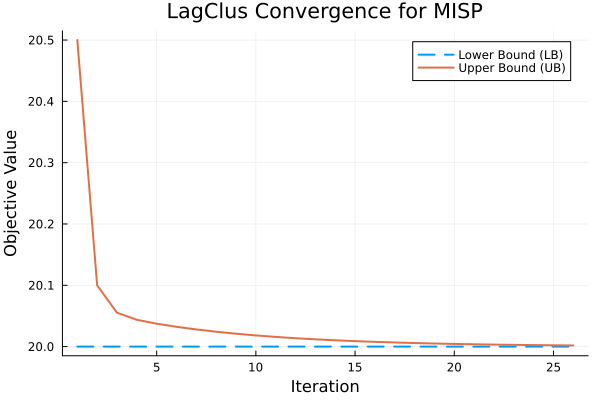

In [7]:
using JuMP          # For mathematical programming
using HiGHS         # HiGHS solver
using Graphs        # Graphs package
using Metis         # For graph partitioning
using LinearAlgebra # For norm calculation
using Printf        # For formatted output

# Utility functions for plotting bounds convergence
include("utils/lr_utils.jl")

# Function to solve MISP exactly
function solve_misp_exact(graph)
    n = Graphs.nv(graph)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n], Bin)
    # Objective: Maximize sum of x[i]
    @objective(model, Max, sum(x[i] for i in 1:n))
    # Constraints: x[u] + x[v] <= 1 for each edge (u,v)
    for e in Graphs.edges(graph)
        u = Graphs.src(e)
        v = Graphs.dst(e)
        @constraint(model, x[u] + x[v] <= 1)
    end
    # Run the solver
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Function to partition graph using Metis
function metis_partition(graph, k)
    partition = Metis.partition(graph, k)
    clusters = [Int[] for _ in 1:k]
    for v in 1:Graphs.nv(graph)
        push!(clusters[partition[v]], v)
    end
    cut_edges = []
    for (e_id, e) in enumerate(Graphs.edges(graph))
        u = Graphs.src(e)
        v = Graphs.dst(e)
        if partition[u] != partition[v]
            push!(cut_edges, (u,v))
        end
    end
    return clusters, cut_edges
end

# Function to create a feasible solution from Lagrangian solution
function create_feasible_solution(graph, lag_solution)
    n = Graphs.nv(graph)
    feasible_solution = copy(lag_solution)
    # Greedily remove conflicts
    for u in 1:n
        if feasible_solution[u] == 1
            for v in Graphs.neighbors(graph, u)
                if feasible_solution[v] == 1
                    # Break tie by degree (drop node with higher degree)
                    if Graphs.degree(graph, u) ≥ Graphs.degree(graph, v)
                        feasible_solution[u] = 0
                    else
                        feasible_solution[v] = 0
                    end
                end
            end
        end
    end
    return feasible_solution
end

# Function to solve Lagrangian subproblem for a cluster
function solve_lagrangian_misp(graph, cluster, λ, solution)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    @variable(model, x[cluster], Bin)

    # Objective: Maximize sum of x[i]
    obj = sum(x[i] for i in cluster)
    
    # Add λ terms to objective and constraints
    for u in cluster
        for v in Graphs.neighbors(graph, u)
            if v in cluster
                if u < v
                    @constraint(model, x[u] + x[v] <= 1)
                end
            else
                if u < v
                    obj -= λ[(u,v)] * x[u]
                else
                    obj -= λ[(v,u)] * x[u]
                end
            end
        end
    end
    @objective(model, Max, obj)

    # Run the solver
    JuMP.optimize!(model)

    # Get the values of the decision variables
    for i in cluster
        solution[i] = JuMP.value(x[i])
    end
    return JuMP.objective_value(model)
end

# Main function to solve MISP using LagClus
function solve_lagclus_misp(graph; max_iterations = 2, k = 2, gap_tolerance = 1e-4, print_feedback_iteration = 10)

    # Get Metis partition
    clusters, cut_edges = metis_partition(graph, k)

    # Initialize Lagrange multipliers for cut edges
    λ = Dict{Tuple{Int,Int}, Float64}()
    for (u,v) in cut_edges
        λ[(u,v)] = 0.1
    end

    # Initialize parameters
    LB = -Inf # Lower bound
    UB = Inf  # Upper bound
    LB_history = [] # Lower bound history
    UB_history = [] # Upper bound history
    θ = 0.8   # A factor to update multiplier (Held-Karp)
    
    # Counter logic for robust convergence
    # Halve θ if UB doesn't improve for 10 iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("------ Starting Optimized Lagrangian Relaxation ------")
    println("Iteration  |  Lower Bound  |  Upper Bound  |   Gap (%)")
    println("-"^54)

    best_feasible_solution = zeros(Graphs.nv(graph))

    for iteration in 1:max_iterations

        # Solve Lagrangian subproblems
        lag_objective = 0.0
        lag_solution = zeros(Graphs.nv(graph))
        for cluster in clusters
            lag_objective += solve_lagrangian_misp(graph, cluster, λ, lag_solution)
        end
        lag_objective += sum(λ[(u,v)] for (u,v) in cut_edges)

        # Update UB (Upper bound)
        if lag_objective < UB
            UB = lag_objective
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Held-Karp Rule: Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                θ *= 0.5
                no_improve_counter = 0
            end
        end
        UB = min(lag_objective, UB)

        # Create a feasible solution by greedy repair
        feasible_solution = create_feasible_solution(graph, lag_solution)
        feasible_objective = sum(feasible_solution)

        if feasible_objective > LB
            LB = feasible_objective    
            best_feasible_solution = copy(feasible_solution)
        end

        # Store history
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Compute gap
        gap = (UB - LB) / UB

        # Print iteration results
        if iteration == 1 || iteration % print_feedback_iteration == 1
            @printf("%10d | %13.4f | %13.4f | %7.3f\n", 
                    iteration, LB, UB, gap * 100)
        end

        # Check convergence
        if gap < gap_tolerance
            println("-"^54)
            println("Converged achieved at iteration $iteration by gap tolerance.")
            break
        end
        
        # Update Lagrange multipliers
        s = []
        for (u,v) in cut_edges
            grad = lag_solution[u] + lag_solution[v] - 1
            λ[(u,v)] = max(0.0, λ[(u,v)] + θ * grad)
            push!(s, grad)
        end
        s = norm(s)

        # Check for small gradient norm
        if s < 1e-6
            println("Subgradient norm small: ", s)
            break
        end
        
        # Adaptive step-size update (Held-Karp)
        θ = 0.2 * ((UB - LB) / (s + 1e-8))
    end

    # Final summary and Exact solve for comparison
    println("-"^54)
    println("Solving exact MIS for comparison...")
    exact_objective = solve_misp_exact(graph)
    @printf("Final UB: %.4f | Exact: %.4f | Duality Gap: %.3f%%\n", 
            UB, exact_objective, 100 * abs(exact_objective- UB)/exact_objective)

    # Plot convergence
    plot_convergence("LagClus Convergence for MISP", LB_history, UB_history, :topright)
end

# Load graph from CSV file
graph = Graphs.loadgraph("data/karate.csv")

# Example usage
solve_lagclus_misp(graph, max_iterations = 200, k=2, gap_tolerance = 1e-4, print_feedback_iteration = 5)

---

## Exercise 7.4

Consider the Generalized Assignment Problem defined with the
following data. Formulate the two Lagrangian relaxations presented in this
chapter and solve by the subgradient method. Compare the limits and the
optimal solution of the problem.

$$
c_{aj} = \begin{pmatrix}
8 & 6 & 10 & 9 & 7 \\
9 & 12 & 7 & 8 & 10 \\
14 & 10 & 9 & 7 & 8
\end{pmatrix}
\quad
r_{aj} = \begin{pmatrix}
2 & 4 & 3 & 2 & 5 \\
3 & 2 & 4 & 3 & 2 \\
5 & 3 & 2 & 4 & 3
\end{pmatrix}
\quad
C_a = \begin{pmatrix}
10 \\ 9 \\ 11
\end{pmatrix}
$$

### Solution

To provide a benchmark for comparison, we first solve the original problem to find the true optimal integer solution using JuMP. Then, we solve the first and second relaxation that provide lower bounds for the original problem.

In [8]:
using JuMP          # Modeling language
using HiGHS         # Solver
using LinearAlgebra # For norm calculations

# GAP Optimal Assignment Problem
function solve_gap_optimal(c,w,C)
    # Problem dimensions
    n, m = size(c)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define binary variables
    @variable(model, x[1:n, 1:m], Bin)
    # Objective: minimize total assignment cost
    @objective(model, Min, sum(c[i, j] * x[i, j] for i in 1:n, j in 1:m))
    # Constraint: each job must be assigned to exactly one agent
    @constraint(model, [j in 1:m], sum(x[i, j] for i in 1:n) == 1)
    # Constraint: agent capacities
    @constraint(model, [i in 1:n], sum(w[i, j] * x[i, j] for j in 1:m) <= C[i])
    # Solve the problem
    JuMP.optimize!(model)
    # Display results
    println("\nOptimal assignment and costs:")
    for i in 1:n, j in 1:m
        if JuMP.value(x[i, j]) > 0.5
            println("Job $j assigned to Agent $i (Cost = $(c[i, j]), Workload = $(w[i, j]))")
        end
    end
    println("\nTotal Cost: ", JuMP.objective_value(model))
end

#--- Lagrangian Relaxation 1: Dualizing Assignment Constraints ---

# Solve the knapsack problem for each agent given the modified costs
function solve_knapsack(costs, weights, capacity)
    n_items = length(costs)
    model = JuMP.Model(HiGHS.Optimizer)
    JuMP.set_silent(model)
    @variable(model, y[1:n_items], Bin)
    @objective(model, Min, dot(costs, y))
    @constraint(model, dot(weights, y) <= capacity)
    JuMP.optimize!(model)
    return JuMP.objective_value(model), JuMP.value.(y)
end

# Subgradient method for Lagrangian Relaxation 1
function subgradient_lr1(c, w, C)
    n,m = size(c)
    λ = zeros(m)
    max_iter = 200
    best_lower_bound = -Inf

    for k in 1:max_iter
        # Solve subproblems (n knapsack problems)
        total_subproblem_obj = 0
        x_sol = zeros(n, m)
        for i in 1:n
            costs_i = c[i, :] .- λ
            weights_i = w[i, :]
            obj_i, x_i = solve_knapsack(costs_i, weights_i, C[i])
            total_subproblem_obj += obj_i
            x_sol[i, :] = x_i
        end

        lower_bound = sum(λ) + total_subproblem_obj
        best_lower_bound = max(best_lower_bound, lower_bound)

        # Subgradient update
        s = 1 .- sum(x_sol, dims=1)[:]
        if norm(s) < 1e-6
            break
        end

        α = 1.0 / k # Step size
        λ .+= α .* s
    end
    return best_lower_bound
end

#--- Lagrangian Relaxation 2: Dualizing Capacity Constraints ---

# Subgradient method for Lagrangian Relaxation 2
function subgradient_lr2(c, w, C)
    n,m = size(c)
    μ = zeros(n)
    max_iter = 200
    best_lower_bound = -Inf

    for k in 1:max_iter
        # Solve subproblems (m simple assignment problems)
        total_subproblem_obj = 0
        x_sol = zeros(n, m)
        for j in 1:m
            costs_j = c[:, j] + μ .* w[:, j]
            min_cost, min_idx = findmin(costs_j)
            total_subproblem_obj += min_cost
            x_sol[min_idx, j] = 1
        end

        lower_bound = -dot(μ, C) + total_subproblem_obj
        best_lower_bound = max(best_lower_bound, lower_bound)

        # Subgradient update
        s = sum(w .* x_sol, dims=2)[:] - C
        if norm(s) < 1e-6
            break
        end

        α = 1.0 / k # Step size
        μ = max.(0, μ + α .* s)
    end
    return best_lower_bound
end

# Cost matrix c[i, j]
c = [
    8  6 10  9  7;
    9 12  7  8 10;
   14 10  9  7  8
]

# Workload matrix w[i, j]
w = [
    2 4 3 2 5;
    3 2 4 3 2;
    5 3 2 4 3
]

# Capacity for each agent
C = [10, 9, 11]

# Run everything
println("Solving GAP Optimal Assignment Problem:")
solve_gap_optimal(c, w, C)

println("\n--- Lagrangian Relaxation ---")
lr1_bound = subgradient_lr1(c, w, C)
println("Lower Bound from Relaxation 1: ", lr1_bound)

lr2_bound = subgradient_lr2(c, w, C)
println("Lower Bound from Relaxation 2: ", lr2_bound)

Solving GAP Optimal Assignment Problem:

Optimal assignment and costs:
Job 1 assigned to Agent 1 (Cost = 8, Workload = 2)
Job 2 assigned to Agent 1 (Cost = 6, Workload = 4)
Job 3 assigned to Agent 2 (Cost = 7, Workload = 4)
Job 4 assigned to Agent 3 (Cost = 7, Workload = 4)
Job 5 assigned to Agent 3 (Cost = 8, Workload = 3)

Total Cost: 36.0

--- Lagrangian Relaxation ---
Lower Bound from Relaxation 1: 29.36515474060723
Lower Bound from Relaxation 2: 35.2


#### Discussion: comparison of the limits and the optimal solution

Comparing the two methods reveals a clear winner for this specific problem instance:

*   **Relaxation 1 Lower Bound:** 29.365
*   **Relaxation 2 Lower Bound:** 35.2
*   **Optimal Cost:** 36.0

**Relaxation 2 provides a much tighter (better) lower bound**, coming very close to the true optimal cost. This indicates that relaxing the capacity constraints (Relaxation 2) results in a problem that is a better approximation of the original GAP than relaxing the assignment constraints (Relaxation 1). The choice of which constraints to relax is crucial and can significantly impact the quality of the resulting bound. In this case, maintaining the "one agent per job" rule while penalizing capacity violations proved to be a more effective estimation strategy.